### Understanding structure of data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [2]:

iris = load_iris(as_frame=True)
data=iris.frame
data


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [3]:

print(iris.keys())
# load_iris?

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [4]:
print("DATA INFO ---")
data.info()
print("DATA DESCRIBE ---")
data.describe()

DATA INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
DATA DESCRIBE ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
data['species']=iris.target_names[data['target']]

### Data visualization

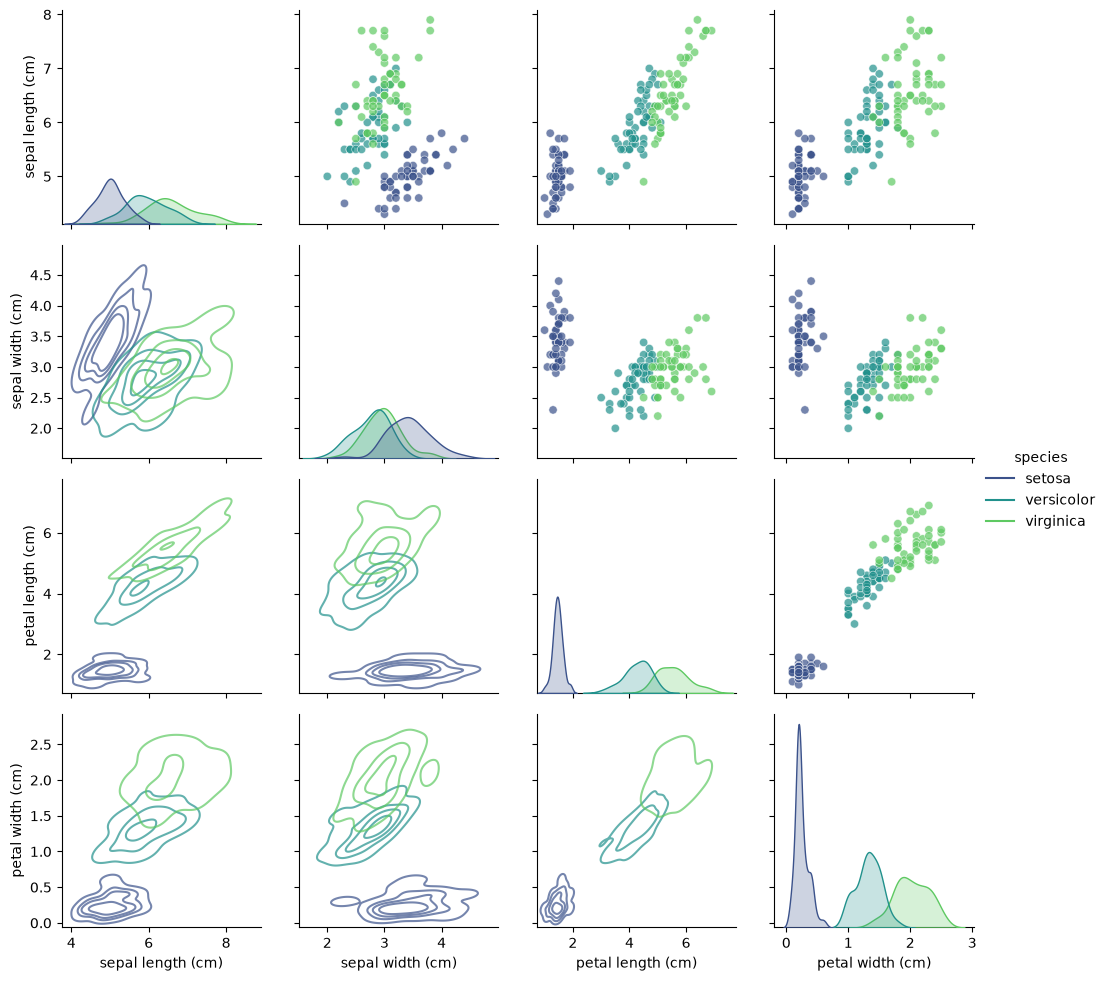

In [6]:

measurement_cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

g = sns.PairGrid(data=data, vars=measurement_cols, hue='species', palette='viridis')
g.map_diag(sns.kdeplot, fill=True, common_norm=False)
g.map_upper(sns.scatterplot, alpha=0.7)
g.map_lower(sns.kdeplot, levels=5, alpha=0.7)
g.add_legend()

plt.show()

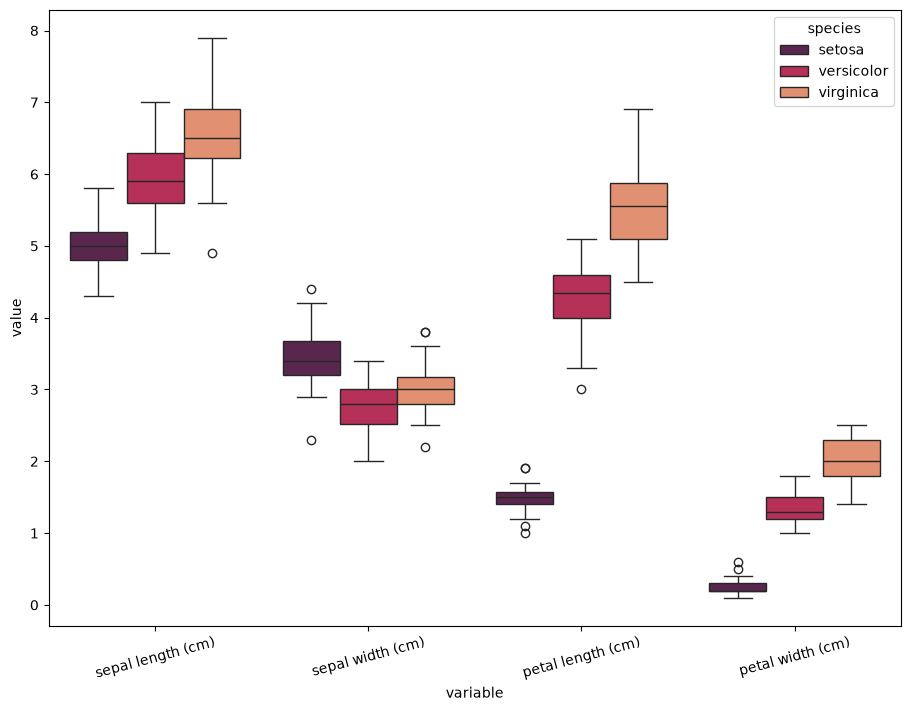

In [7]:
plt.figure(figsize=(11,8))

melted_data = pd.melt(data, id_vars='species', value_vars=measurement_cols)
sns.boxplot(data=melted_data, x='variable', y='value', hue='species', palette='rocket')
plt.xticks(rotation=15)
plt.show()

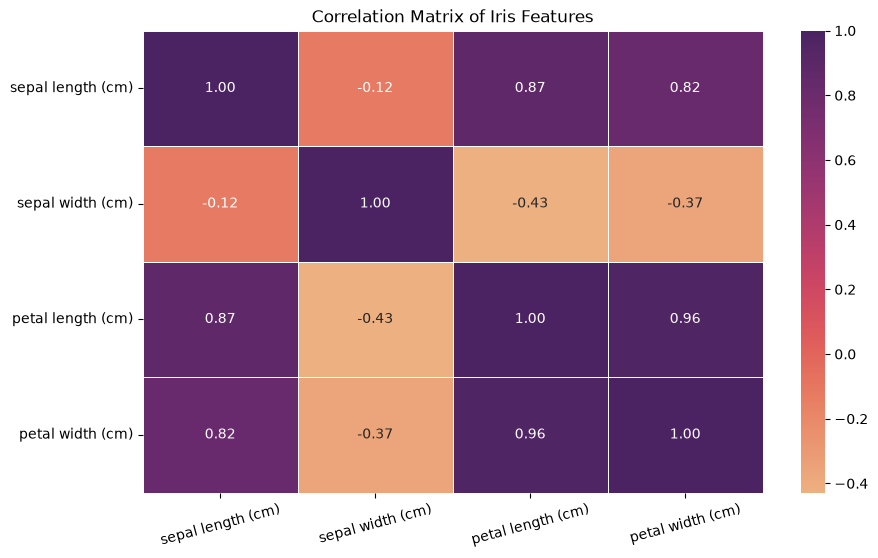

In [8]:
plt.figure(figsize=(10, 6))

corr_matrix = data[measurement_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='flare', fmt=".2f", linewidths=0.5 )
plt.title("Correlation Matrix of Iris Features")
plt.xticks(rotation=15)
plt.show()

### The Findings --

- sepal width increases, the petal dimensions  tend to decrease slightly
- sepal length is showing High corr with petal length and petal width .
- Sepal width is  showing tends to zero  corr with sepal length .
- Setosa has smallest petal length and width 
- Outliers 
    - setosa has highest outliers in category of sepal width , petal length , petal width 
- virginica has longest sepal and petal lengths

### Machine learning Parameters ---
- Petal length and petal width are sufficient to predict the category for inputs .
- Setosa is seperate in data (no overlapping )
- some overlapping exist in vericolor and verginica and might give wrong prediction in range ( 4.5 , 1.5 )
